# Sistema Difuso - Compatibilidad de Pelicula/Serie (SKFuzzy)

**Punto 2.** Calcula que tan compatible es una pelicula/serie con la persona segun la duracion del contenido, el tiempo libre disponible y el interes por el genero.

## 1. Instalar e importar la libreria

In [1]:
!pip install -U scikit-fuzzy
print("ok install")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 14.0 MB/s eta 0:00:00
ok install


In [2]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt
print("ok import")

ok import


## 2. Variables y conjuntos difusos

In [3]:
duracion = ctrl.Antecedent(np.arange(0, 241, 1), 'duracion')
tiempo_disponible = ctrl.Antecedent(np.arange(0, 301, 1), 'tiempo_disponible')
interes_genero = ctrl.Antecedent(np.arange(0, 11, 1), 'interes_genero')
compatibilidad = ctrl.Consequent(np.arange(0, 101, 1), 'compatibilidad')

duracion['corta'] = fuzz.trapmf(duracion.universe, [0, 0, 60, 90])
duracion['media'] = fuzz.trimf(duracion.universe, [70, 110, 150])
duracion['larga'] = fuzz.trapmf(duracion.universe, [130, 180, 240, 240])

tiempo_disponible['poco'] = fuzz.trapmf(tiempo_disponible.universe, [0, 0, 60, 120])
tiempo_disponible['medio'] = fuzz.trimf(tiempo_disponible.universe, [60, 120, 180])
tiempo_disponible['mucho'] = fuzz.trapmf(tiempo_disponible.universe, [150, 220, 300, 300])

interes_genero['bajo'] = fuzz.trapmf(interes_genero.universe, [0, 0, 2, 5])
interes_genero['medio'] = fuzz.trimf(interes_genero.universe, [3, 5, 7])
interes_genero['alto'] = fuzz.trapmf(interes_genero.universe, [5, 8, 10, 10])

compatibilidad['baja'] = fuzz.trapmf(compatibilidad.universe, [0, 0, 25, 50])
compatibilidad['media'] = fuzz.trimf(compatibilidad.universe, [30, 50, 70])
compatibilidad['alta'] = fuzz.trapmf(compatibilidad.universe, [50, 80, 100, 100])
print('ok variables y conjuntos')

ok variables y conjuntos


## 3. Reglas difusas

In [4]:
reglas = [
    ctrl.Rule(interes_genero['alto'], compatibilidad['alta']),
    ctrl.Rule(interes_genero['bajo'], compatibilidad['baja']),
    ctrl.Rule(duracion['larga'] & tiempo_disponible['poco'], compatibilidad['baja']),
    ctrl.Rule(duracion['corta'] & tiempo_disponible['mucho'], compatibilidad['alta']),
    ctrl.Rule(interes_genero['medio'] & tiempo_disponible['medio'], compatibilidad['media']),
    ctrl.Rule(duracion['media'] & interes_genero['medio'], compatibilidad['media']),
    ctrl.Rule(tiempo_disponible['mucho'] & interes_genero['alto'], compatibilidad['alta']),
]
sistema_ctrl = ctrl.ControlSystem(reglas)
print(f'ok reglas cargadas: {len(reglas)}')

ok reglas cargadas: 7


## 4. Prueba rapida con valores fijos

Salida: 81.42857142857143


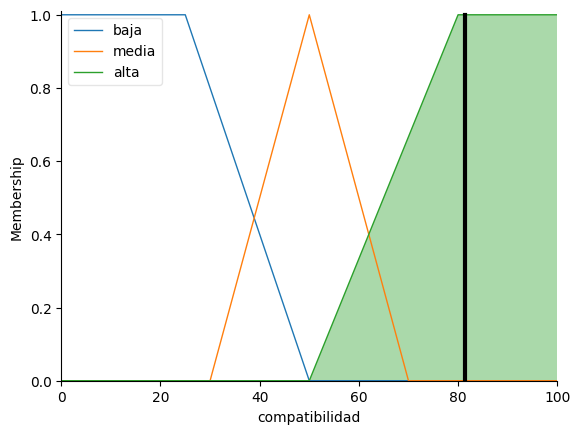

In [5]:
# Prueba rapida con valores fijos (igual que el ejercicio del mesero visto en clase)
sim = ctrl.ControlSystemSimulation(sistema_ctrl)
sim.input['duracion'] = 60
sim.input['tiempo_disponible'] = 250
sim.input['interes_genero'] = 9
sim.compute()
print("Salida:", sim.output['compatibilidad'])
compatibilidad.view(sim=sim)
plt.show()

## 5. Interfaz grafica de usuario (ipywidgets)

Mueve los deslizadores y presiona **Calcular**.

In [6]:
import ipywidgets as widgets
from IPython.display import display, clear_output
print("ok import widgets")

ok import widgets


In [7]:
sliders = {}
sliders['duracion'] = widgets.FloatSlider(value=100, min=0, max=240, step=5, description='Duracion (min)', style={'description_width': 'initial'}, layout=widgets.Layout(width='500px'))
sliders['tiempo_disponible'] = widgets.FloatSlider(value=150, min=0, max=300, step=5, description='Tiempo disponible (min)', style={'description_width': 'initial'}, layout=widgets.Layout(width='500px'))
sliders['interes_genero'] = widgets.FloatSlider(value=7, min=0, max=10, step=1, description='Interes por el genero (0-10)', style={'description_width': 'initial'}, layout=widgets.Layout(width='500px'))

boton = widgets.Button(description="Calcular", button_style="success")
salida = widgets.Output()

def al_hacer_click(b):
    with salida:
        clear_output()
        sim = ctrl.ControlSystemSimulation(sistema_ctrl)
        for nombre_var, widget in sliders.items():
            sim.input[nombre_var] = widget.value
        sim.compute()
        valor = sim.output['compatibilidad']
        if valor < 40:
            categoria = "BAJA"
        elif valor < 65:
            categoria = "MEDIA"
        else:
            categoria = "ALTA"
        print(f"Resultado = {valor:.1f} / 100  ->  {categoria}")
        compatibilidad.view(sim=sim)
        plt.show()

boton.on_click(al_hacer_click)

display(widgets.VBox(list(sliders.values()) + [boton, salida]))